# Лабораторная работа 3

Тема: **Многослойный персептрон (MLP) на NumPy**  
Цель: своими руками построить и исследовать многослойный персептрон с одним скрытым слоем для двумерной задачи классификации.

> Этот ноутбук предназначен **именно для практической работы**.  
> Если вы попытаетесь загрузить его целиком в генеративный сервис, получится либо бессодержательный, либо легко распознаваемый преподавателем текст.  
> Основная часть баллов ставится за:
> - ваш код и экспериментальные решения;
> - ваши формулировки выводов (со своим стилем и примерами);
> - осмысленные выборы параметров и их обсуждение.


## 1. "Человеческое" объяснение задачи

Прежде чем писать код, попробуйте **по‑человечески** сформулировать, что вы собираетесь сделать.

Ответьте своими словами:
1. Чем многослойный персептрон отличается от однослойного? Можно представить это неформально, без терминов «гиперплоскость», «аппроксиматор» и т.п.
2. Что именно делает скрытый слой: как бы вы объяснили его смысл школьнику, который знает только про «линейные формулы»?
3. Как вы ожидаете, будет выглядеть граница между двумя запутанными классами из точек, если у сети **нет** скрытого слоя, и как она может выглядеть, если скрытый слой есть?

Не старайтесь выдавать «правильные определения» из учебника: здесь ценится живое объяснение и ваши собственные ассоциации.


In [16]:
intro_text = """ЗДЕСЬ НАПИШИТЕ СВОЁ ОБЪЯСНЕНИЕ ЗАДАЧИ.
Представьте, что рассказываете другу, который не любит формальные определения,
но готов слушать примеры и сравнения с чем‑то из реальной жизни.

1. Многослойный персептрон в отличии от однослойного не ограничивается только прямой решающей границей при разделении классов. Она может быть в любой форме, отделяя классы точнее и качественнее.
2. Скрытый слой ищет закономерности и делает гораздо больше действий при разделении классов, например, как повар при готовке не просто кладет ингридиенты в тарелку, а перед этим моет их, режет, жарит/варит, и только потом подает в виде готового блюда.
3. Если не будет скрытого слоя, то, мне кажется, что граница будет прямой. А если есть, то уже какой-то извилистой/ломанной."""
print(intro_text)

ЗДЕСЬ НАПИШИТЕ СВОЁ ОБЪЯСНЕНИЕ ЗАДАЧИ.
Представьте, что рассказываете другу, который не любит формальные определения,
но готов слушать примеры и сравнения с чем‑то из реальной жизни.

1. Многослойный персептрон в отличии от однослойного не ограничивается только прямой решающей границей при разделении классов. Она может быть в любой форме, отделяя классы точнее и качественнее.
2. Скрытый слой ищет закономерности и делает гораздо больше действий при разделении классов, например, как повар при готовке не просто кладет ингридиенты в тарелку, а перед этим моет их, режет, жарит/варит, и только потом подает в виде готового блюда.
3. Если не будет скрытого слоя, то, мне кажется, что граница будет прямой. А если есть, то уже какой-то извилистой/ломанной.


## 2. Настройка среды и генерация данных

В этой работе мы будем использовать:
- `numpy` для вычислений,
- `matplotlib` для рисования картинок.

Сначала нужно:
- импортировать библиотеки;
- зафиксировать `seed` для воспроизводимости (можете выбрать своё число);
- сгенерировать двумерный набор точек двух классов, которые **не** разделяются одной прямой (например, два «полумесяца» или что‑то аналогичное).

Важно: форму и распределение данных вы выбираете сами (обоснование — в выводах). Ниже приведён один из возможных вариантов генерации.


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Задайте любой seed, который вам нравится (но используйте его последовательно)
np.random.seed(0)
plt.style.use("seaborn-v0_8")

print("Библиотеки импортированы, seed установлен.")

Библиотеки импортированы, seed установлен.


Форма X: (500, 2)
Форма y: (500,)


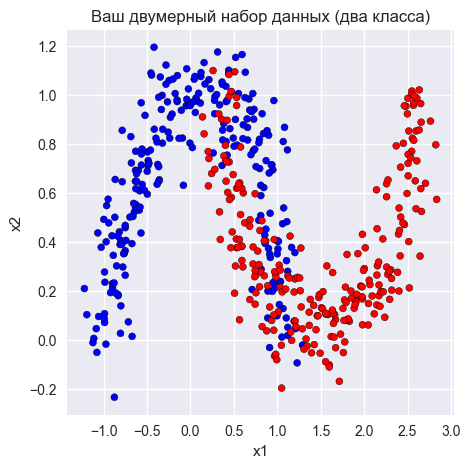

In [18]:
def make_curved_two_class_data(n_samples, noise=0.15):
    # TODO: Придумайте себе картинку: две дуги, два кольца, или другой не-линейный рисунок на плоскости.
    """
    Ниже — один из вариантов для демонстрации (две изогнутые полосы).
    """
    n1 = n_samples // 2
    n2 = n_samples - n1

    # Первая дуга
    theta1 = np.linspace(0, np.pi, n1)
    r1 = 1.0 + 0.1 * np.sin(2 * theta1)
    x1 = np.c_[r1 * np.cos(theta1), r1 * np.sin(theta1)]

    # Вторая дуга (смещённая)
    theta2 = np.linspace(0, np.pi, n2)
    r2 = 1.0 + 0.1 * np.cos(2 * theta2)
    x2 = np.c_[1.5 - r2 * np.cos(theta2), 1.0 - r2 * np.sin(theta2)]

    X = np.vstack([x1, x2])
    y = np.hstack([np.zeros(n1), np.ones(n2)])

    X += noise * np.random.randn(*X.shape)
    return X, y

X, y = make_curved_two_class_data(n_samples=500, noise=0.12)

print("Форма X:", X.shape)
print("Форма y:", y.shape)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="black", s=25)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Ваш двумерный набор данных (два класса)")
plt.grid(True)
plt.show()

Разделите данные на обучающую и тестовую части.  
Доле тестовой выборки (например, 20–30%) дайте осмысленный комментарий в выводах: почему выбрали именно её.


In [19]:
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

test_ratio = 0.20  # можете поменять на свой вариант
n_test = int(len(indices) * test_ratio)

test_idx = indices[:n_test]
train_idx = indices[n_test:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print("Размер train:", X_train.shape)
print("Размер test :", X_test.shape)

Размер train: (400, 2)
Размер test : (100, 2)


In [20]:
two_class_data_text = """ЗДЕСЬ НАПИШИТЕ СВОЁ ОБОСНОВАНИЕ ВЫБОРА ФОРМЫ И РАСПРЕДЕЛЕНИЯ ДАННЫХ 
И ИХ РАЗДЕЛЕНИЯ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ.

Я выбрал долю обучающей выборки в 20% и считаю это оптимальным для такого датасета, потому что модели необходим больший процент для тестовой выборки, для качественного и точного результата. 
И меньшая доля обучающей части позволит нейросети выявлять закономерности в более обобщенном виде."""
print(two_class_data_text)

ЗДЕСЬ НАПИШИТЕ СВОЁ ОБОСНОВАНИЕ ВЫБОРА ФОРМЫ И РАСПРЕДЕЛЕНИЯ ДАННЫХ 
И ИХ РАЗДЕЛЕНИЯ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ.

Я выбрал долю обучающей выборки в 20% и считаю это оптимальным для такого датасета, потому что модели необходим больший процент для тестовой выборки, для качественного и точного результата. 
И меньшая доля обучающей части позволит нейросети выявлять закономерности в более обобщенном виде.


## 3. Активации, функция потерь и точность

Вам потребуется:
- одна нелинейная функция для скрытого слоя (например, ReLU или tanh);
- сигмоида на выходе (чтобы интерпретировать результат как вероятность);
- функция потерь (бинарная кросс-энтропия);
- метрика точности.

Реализации ниже — отправная точка. В реальной работе вы можете экспериментировать с другими активациями, но должны уметь объяснить, что и зачем вы делаете.


In [21]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return np.mean(loss)

def accuracy_score(y_true, y_pred_labels):
    return np.mean(y_true == y_pred_labels)

# Быстрая самопроверка
test_z = np.array([-1.0, 0.0, 2.0])
print("ReLU:", relu(test_z))
print("sigmoid:", sigmoid(test_z))

ReLU: [0. 0. 2.]
sigmoid: [0.26894142 0.5        0.88079708]


In [22]:
activation_text = """ЗДЕСЬ НАПИШИТЕ СВОЁ ОБОСНОВАНИЕ ВЫБОРА АКТИВАЦИИ.

Я оставил ReLU, потому что в ней не требуется вычисления экспоненты (как, например, в tanh), а сигмоидальную функцию на выход - с ней уже работал больше в первой лабораторной работе."""
print(activation_text )

ЗДЕСЬ НАПИШИТЕ СВОЁ ОБОСНОВАНИЕ ВЫБОРА АКТИВАЦИИ.

Я оставил ReLU, потому что в ней не требуется вычисления экспоненты (как, например, в tanh), а сигмоидальную функцию на выход - с ней уже работал больше в первой лабораторной работе.


## 4. Архитектура MLP и прямой проход

Мы будем использовать сеть вида:
- входной размер = 2 (координаты точки);
- скрытый слой: `H` нейронов (значение `H` вы выбираете сами и обосновываете в выводах);
- выход: 1 нейрон (вероятность класса 1).

От вас требуется:
1. Инициализировать веса и смещения разумным образом (не все нули).  
2. Реализовать прямой проход `mlp_forward`, который возвращает выходы и промежуточные значения (для backprop).

Объяснение всех размерностей и матриц/векторов желательно держать рядом на бумаге — так проще отлавливать ошибки.


In [23]:
def init_mlp_params(n_input, n_hidden, n_output):
    """Инициализация параметров MLP.

    Подумайте, почему веса не стоит делать слишком большими по модулю.
    """
    #TODO: Попробуйте разные варианты инициализации весов
    W1 = 0.1 * np.random.randn(n_hidden, n_input)
    b1 = np.zeros((n_hidden, 1))
    W2 = 0.1 * np.random.randn(n_output, n_hidden)
    b2 = np.zeros((n_output, 1))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def mlp_forward(X, params):
    """Прямой проход MLP.

    X: (n_samples, n_features)
    params: словарь с W1, b1, W2, b2
    """
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]

    X_T = X.T  # (n_features, n_samples)
    Z1 = W1 @ X_T + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)

    cache = {"X_T": X_T, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

n_input = 2
n_hidden = 1000  # TODO: попробуйте несколько значений
n_output = 1

params = init_mlp_params(n_input, n_hidden, n_output)
A2_demo, cache_demo = mlp_forward(X_train[:5], params)
print("Форма выхода A2_demo:", A2_demo.shape)

Форма выхода A2_demo: (1, 5)


## 5. Обратный проход (backpropagation)

Здесь важно не просто «написать формулы», а осознать, как градиент проходит через слои.

Рекомендация:
- Перед написанием кода нарисуйте цепочку преобразований вида: X → Z1 → A1 → Z2 → A2 → loss.
- Отметьте, какие производные вам нужны: \(\partial L/\partial Z2\), \(\partial L/\partial W2\), \(\partial L/\partial Z1\) и т.д.

Ниже — одна из реализаций, которую при желании можно модифицировать под свои эксперименты.


In [24]:
def mlp_backward(y_true, params, cache):
    """Обратный проход: вычисление градиентов для всех параметров.

    y_true: (n_samples,) — метки 0/1
    """
    W1, W2 = params["W1"], params["W2"]
    X_T = cache["X_T"]
    Z1, A1 = cache["Z1"], cache["A1"]
    Z2, A2 = cache["Z2"], cache["A2"]

    n_samples = X_T.shape[1]
    y_true = y_true.reshape(1, -1)

    # dL/dZ2 (для сигмоиды + бинарной кросс-энтропии)
    dZ2 = A2 - y_true                   # (1, n_samples)
    dW2 = (1 / n_samples) * dZ2 @ A1.T  # (1, n_hidden)
    db2 = (1 / n_samples) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = W2.T @ dZ2                    # (n_hidden, n_samples)
    dZ1 = dA1 * relu_derivative(Z1)     # (n_hidden, n_samples)
    dW1 = (1 / n_samples) * dZ1 @ X_T.T # (n_hidden, n_input)
    db1 = (1 / n_samples) * np.sum(dZ1, axis=1, keepdims=True)

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

# Проверка размеров градиентов на маленьком фрагменте данных
grads_demo = mlp_backward(y_train[:5], params, cache_demo)
for name, g in grads_demo.items():
    print(name, g.shape)

dW1 (1000, 2)
db1 (1000, 1)
dW2 (1, 1000)
db2 (1, 1)


## 6. Обучение MLP: цикл эпох

Теперь объединяем всё в единый цикл обучения:
- прямой проход на train,
- расчёт потерь и точности на train и test,
- обратный проход,
- обновление параметров.

Важно не только «получить высокую точность», но и потом честно описать, как меняется качество при других настройках (другая скорость обучения, другое число нейронов и т.д.).


In [25]:
def train_mlp(X_train, y_train, X_test, y_test,
              n_hidden=8, n_epochs=1500, lr=0.1, print_every=300):
    n_input = X_train.shape[1]
    n_output = 1
    params = init_mlp_params(n_input, n_hidden, n_output)

    history = {"train_loss": [], "test_loss": [],
               "train_acc": [], "test_acc": []}

    for epoch in range(1, n_epochs + 1):
        # Прямой проход (train)
        A2_train, cache_train = mlp_forward(X_train, params)
        y_train_prob = A2_train.ravel()
        loss_train = binary_cross_entropy(y_train, y_train_prob)
        y_train_pred = (y_train_prob >= 0.5).astype(int)
        acc_train = accuracy_score(y_train, y_train_pred)

        # Прямой проход (test)
        A2_test, _ = mlp_forward(X_test, params)
        y_test_prob = A2_test.ravel()
        loss_test = binary_cross_entropy(y_test, y_test_prob)
        y_test_pred = (y_test_prob >= 0.5).astype(int)
        acc_test = accuracy_score(y_test, y_test_pred)

        history["train_loss"].append(loss_train)
        history["test_loss"].append(loss_test)
        history["train_acc"].append(acc_train)
        history["test_acc"].append(acc_test)

        # Обратный проход и шаг градиентного спуска
        grads = mlp_backward(y_train, params, cache_train)
        params["W1"] -= lr * grads["dW1"]
        params["b1"] -= lr * grads["db1"]
        params["W2"] -= lr * grads["dW2"]
        params["b2"] -= lr * grads["db2"]

        if epoch % print_every == 0:
            print(f"Эпоха {epoch}/{n_epochs}: "
                  f"train_loss={loss_train:.3f}, train_acc={acc_train:.3f}, "
                  f"test_loss={loss_test:.3f}, test_acc={acc_test:.3f}")

    return params, history

params_trained, history = train_mlp(
    X_train, y_train, X_test, y_test,
    n_hidden=n_hidden, n_epochs=1500, lr=0.1, print_every=300
)

print("Обучение завершено.")

Эпоха 300/1500: train_loss=0.358, train_acc=0.800, test_loss=0.292, test_acc=0.870
Эпоха 600/1500: train_loss=0.345, train_acc=0.810, test_loss=0.287, test_acc=0.880
Эпоха 900/1500: train_loss=0.330, train_acc=0.835, test_loss=0.279, test_acc=0.890
Эпоха 1200/1500: train_loss=0.311, train_acc=0.853, test_loss=0.270, test_acc=0.900
Эпоха 1500/1500: train_loss=0.292, train_acc=0.875, test_loss=0.262, test_acc=0.910
Обучение завершено.


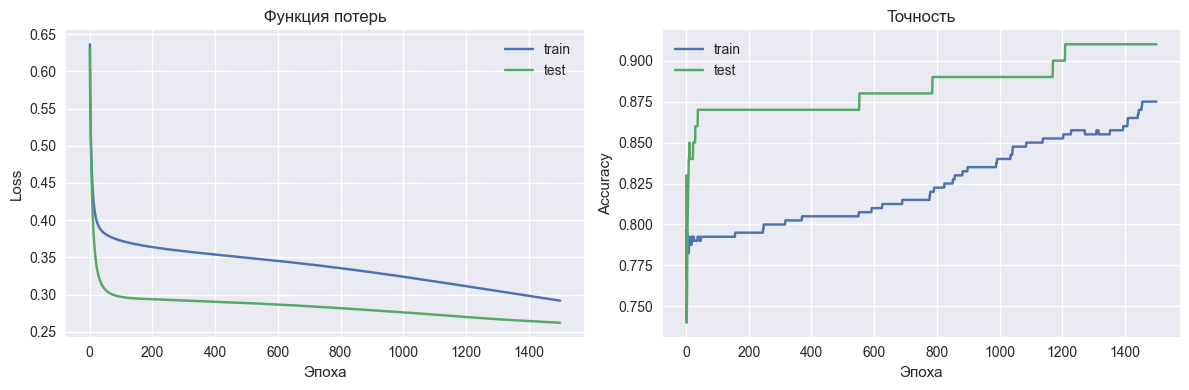

Финальная точность: train=0.875, test=0.910


In [26]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.3f}, test={history['test_acc'][-1]:.3f}")

## 7. Как выглядит решающая граница MLP

Теперь давайте посмотрим не только на числа, но и на геометрию решения:  
построим карту вероятностей принадлежности к классу 1 на сетке точек и наложим на неё обучающие данные.

Это лучший способ проверить, действительно ли сеть "понимает" структуру ваших классов, а не просто запомнила отдельные точки.


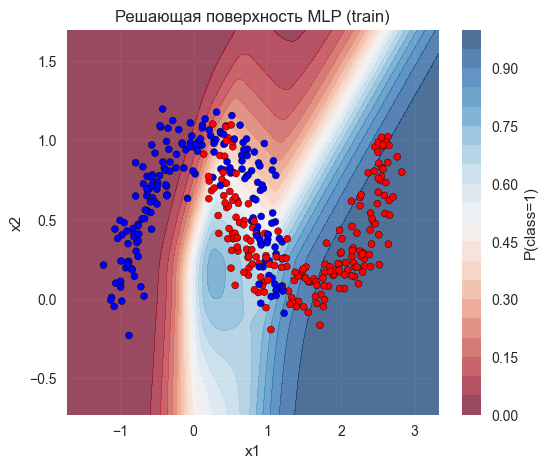

In [27]:
def plot_mlp_decision_surface(X, y, params, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    A2_grid, _ = mlp_forward(grid, params)
    probs = A2_grid.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    cs = plt.contourf(xx, yy, probs, levels=20, cmap="RdBu", alpha=0.7)
    plt.colorbar(cs, label="P(class=1)")

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="black", s=25)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_mlp_decision_surface(X_train, y_train, params_trained,
                          "Решающая поверхность MLP (train)")

## 8. (Опционально) Сравнение с линейной моделью

Если хотите убедиться, что скрытый слой **действительно** нужен, попробуйте:
- реализовать простой линейный классификатор (один слой + сигмоида),
- обучить его на тех же данных,
- построить решающую границу для него и сравнить с MLP.

Здесь можно использовать упрощённый вариант (логистическая регрессия на NumPy). Эта часть не обязательна, но полезна для понимания.


In [28]:
def train_linear_classifier(X_train, y_train, X_test, y_test,
                            lr=0.5, n_epochs=2000):
    n_samples, n_features = X_train.shape
    w = np.zeros((n_features, 1))
    b = 0.0

    for _ in range(n_epochs):
        X_T = X_train.T
        z = w.T @ X_T + b
        a = sigmoid(z)
        y_true = y_train.reshape(1, -1)
        dz = a - y_true
        dw = (1 / n_samples) * (dz @ X_T.T).T
        db = (1 / n_samples) * np.sum(dz)
        w -= lr * dw
        b -= lr * db

    # Оценка
    z_tr = (w.T @ X_train.T + b).ravel()
    a_tr = sigmoid(z_tr)
    y_tr_pred = (a_tr >= 0.5).astype(int)
    acc_tr = accuracy_score(y_train, y_tr_pred)

    z_te = (w.T @ X_test.T + b).ravel()
    a_te = sigmoid(z_te)
    y_te_pred = (a_te >= 0.5).astype(int)
    acc_te = accuracy_score(y_test, y_te_pred)

    return w, b, acc_tr, acc_te

w_lin, b_lin, acc_tr_lin, acc_te_lin = train_linear_classifier(
    X_train, y_train, X_test, y_test, lr=0.5, n_epochs=2500
)

print(f"Линейная модель: train_acc={acc_tr_lin:.3f}, test_acc={acc_te_lin:.3f}")

Линейная модель: train_acc=0.775, test_acc=0.880


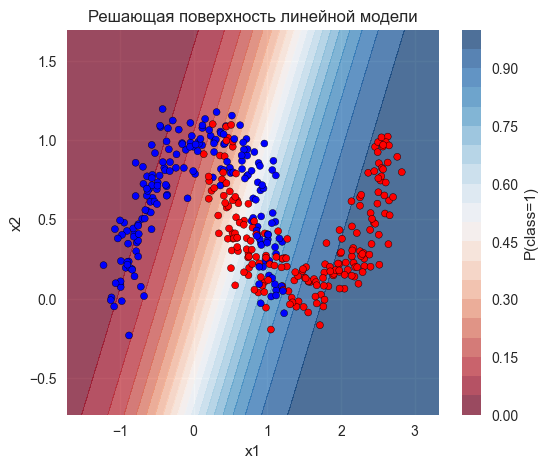

In [29]:
def plot_linear_surface(X, y, w, b, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    z = (w.T @ grid.T + b).ravel()
    probs = sigmoid(z).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    cs = plt.contourf(xx, yy, probs, levels=20, cmap="RdBu", alpha=0.7)
    plt.colorbar(cs, label="P(class=1)")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="black", s=25)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_linear_surface(X_train, y_train, w_lin, b_lin,
                    "Решающая поверхность линейной модели")

## 9. Итог: ваши личные выводы

Самая ценная часть работы — не код, а выводы, которые вы делаете на основе собственных экспериментов.

Ответьте:
1. Какое число нейронов в скрытом слое вы в итоге выбрали и почему (опишите 1–2 других варианта, которые пробовали)?
2. Как вели себя функции потерь и точности по эпохам: было ли переобучение, стагнация, резкие скачки?
3. Чем визуально отличается решающая граница MLP от границы линейной модели на ваших данных?
4. Как бы вы объяснили **на своём примере**, зачем вообще нужны скрытые слои, человеку, который видел только линейные модели?

Не ограничивайтесь шаблонной фразой «MLP решает нелинейные задачи» — привяжите ответы к конкретным картинкам и числам из своих экспериментов.


In [30]:
final_comment = """ЗДЕСЬ НАПИШИТЕ СВОИ ИТОГОВЫЕ ВЫВОДЫ.
Сошлитесь на конкретные эксперименты, которые вы провели: числа нейронов, lr,
число эпох, формы решающих границ. Представьте, что вам нужно объяснить эту
лабораторную будущему себе через год — так, чтобы он сразу все вспомнил.

1. Пробовал единицу - там все как в линейной функции, как с однослойным персептроном в целом. Расхождения начались уже на значении 2 - в низу графика появилсь изломы.
Потом при 1000 - граница стала более подстраиваться под дуги, и на прямую уже никак не похожа.

2. По наблюдению, стагнация была на точности как у тестовой, так и у обучающей выборки (можно заметить ступенчатость на графиках), но все же видно увеличение точности.
Резкий скачок точности был у тестовой выборки в самые первые (примерно 10) эпохи.
Потери стремительно убывали, резкий скачок был также в первые эпохи. Функция потерь более плавная, и стагнации не наблюдается.

3. Решающая граница MLP от линейной модели отличается своей нелинейностью - на графике MLP можно заметить, что с увеличением нейронов скрытого слоя, граница подстраивается под классы точнее и точнее.
В итоге граница становится более похожей на линию с убывающей и возрастающей гиперболами, каковыми являются изначальные данные расположения точек.

4. Скрытые слои, грубо говоря, для облегчения жизни программистов. С их помощью можно разделять нелинейно разделимые функции, как, например, в этой лабораторной работе или XOR из предыдущей.
MLP может разделить и простейшие функции AND или OR, но для них он избыточен, т.к. их можно делить и линейной функцией.
А также человеку, который видел только линейные функции, конечно, скрытые слои помогут в расширении кругозора, ведь бинарный мир не ограничивается только линейностью."""
print(final_comment)

ЗДЕСЬ НАПИШИТЕ СВОИ ИТОГОВЫЕ ВЫВОДЫ.
Сошлитесь на конкретные эксперименты, которые вы провели: числа нейронов, lr,
число эпох, формы решающих границ. Представьте, что вам нужно объяснить эту
лабораторную будущему себе через год — так, чтобы он сразу все вспомнил.

1. Пробовал единицу - там все как в линейной функции, как с однослойным персептроном в целом. Расхождения начались уже на значении 2 - в низу графика появилсь изломы.
Потом при 1000 - граница стала более подстраиваться под дуги, и на прямую уже никак не похожа.

2. По наблюдению, стагнация была на точности как у тестовой, так и у обучающей выборки (можно заметить ступенчатость на графиках), но все же видно увеличение точности.
Резкий скачок точности был у тестовой выборки в самые первые (примерно 10) эпохи.
Потери стремительно убывали, резкий скачок был также в первые эпохи. Функция потерь более плавная, и стагнации не наблюдается.

3. Решающая граница MLP от линейной модели отличается своей нелинейностью - на графике MLP мож